#Attractions Dataset

##Import libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Text cleaning
import re
import string

# Text vecotrizing and similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Saving the models
import joblib

##Load Dataset

In [2]:
df = pd.read_csv('/content/UAE_Attractions_Final.csv')
df.head()

,Attraction_ID,Name,City,Location,Description,Categories,Environment,price_level,Avg_Rating,Reviews
0,1001,Abrahamic Family House,Abu Dhabi,Saadiyat Island,A cultural and religious complex containing a ...,"Religious, Cultural, Architecture, Educational","Indoor, Outdoor",Free,4.5,Abrahamic Family House is built on a truly mea...
1,1002,Abu Dhabi Corniche,Abu Dhabi,Corniche Road,"A long waterfront promenade with beaches, cycl...","Waterfront, Beach, Cycling, Family",Outdoor,Free,4.5,It’s a safest beach. Clean and good atmosphere...
2,1003,Abu Dhabi Falcon Hospital,Abu Dhabi,Sweihan Road,A specialist falcon hospital offering educatio...,"Wildlife, Cultural, Educational",Indoor,Medium,4.3,Absolutely worth visiting. No matter if you ha...
3,1004,Abu Dhabi National Exhibition Centre,Abu Dhabi,Al Rawdah,A large exhibition and conference venue hostin...,"Events, Exhibition, Business",Indoor,Varies,4.6,⭐⭐⭐⭐⭐ (5/5)\nAs an advertising and exhibition ...
4,1005,Adrenark Adventure,Abu Dhabi,Al Qana,"An indoor adventure park with climbing, obstac...","Adventure, Family, Sports",Indoor,High,4.5,Amazing place with lot of activities for kids ...


##Data Inspection

In [3]:
df.shape

(520, 10)

In [4]:
df.columns

Index(['Attraction_ID', 'Name', 'City', 'Location', 'Description',
       'Categories', 'Environment', 'price_level', 'Avg_Rating', 'Reviews'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Attraction_ID  520 non-null    int64  
 1   Name           520 non-null    object 
 2   City           520 non-null    object 
 3   Location       520 non-null    object 
 4   Description    520 non-null    object 
 5   Categories     520 non-null    object 
 6   Environment    520 non-null    object 
 7   price_level    520 non-null    object 
 8   Avg_Rating     505 non-null    float64
 9   Reviews        504 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 40.8+ KB


In [6]:
df['Attraction_ID'].duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

,0
Attraction_ID,0
Name,0
City,0
Location,0
Description,0
Categories,0
Environment,0
price_level,0
Avg_Rating,15
Reviews,16


In [8]:
pd.set_option("display.max_colwidth", 200)

df[["Reviews", "Avg_Rating"]].sample(5, random_state=42)

,Reviews,Avg_Rating
275,"Dubai College of Tourism (DCT) is a vocational education institution established by Dubai’s Department of Economy and Tourism. It offers certificate and advanced diploma programmes in tourism, hos...",4.7
93,"This is my 2nd time attending this competiion,\nThe atmosphere is amazing. Great venue, Tickets is affordable too. We will definitely attend and support this event every year. Credit to Mubadala a...",4.6
6,"Hidden Gem in Al Reem Island\n\nThis is easily one of the most underrated and best maintained parks in Al Reem Island. From the outside, it looks like a regular neighborhood park, but once you ste...",4.5
167,"The Dubai Aquarium is absolutely outstanding and one of the most impressive attractions we have ever visited.\n\nEven from the outside, viewing the enormous aquarium through Dubai Mall is already ...",4.5
90,"Umm Al Emarat Park, formerly known as Mushrif Park, is a prominent urban park located in the heart of Abu Dhabi. Originally opened in 1982, it was initially exclusive to women and children but has...",4.6


The reviews are split by ||, In addition, it includes emojis. Missing values in avg ratings and reviews will remain na and will not be used in the final recommendation calculation.

In [9]:
# Rating Distribution
df["Avg_Rating"].value_counts().sort_index(ascending = False)

,count
Avg_Rating,
5.0,3
4.9,3
4.8,27
4.7,65
4.6,103
4.5,118
4.4,87
4.3,52
4.2,17


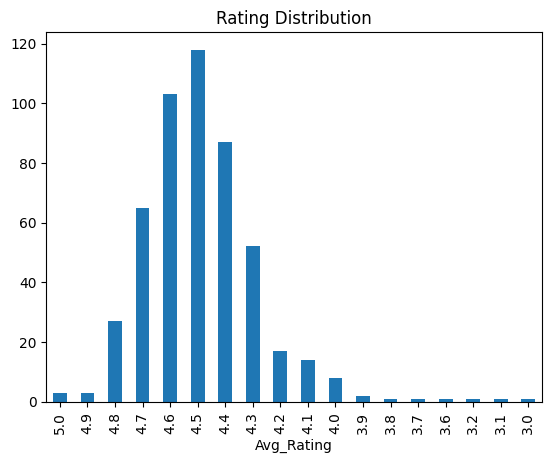

In [10]:
df["Avg_Rating"].value_counts().sort_index(ascending = False).plot(kind = "bar", title = "Rating Distribution")
plt.show()

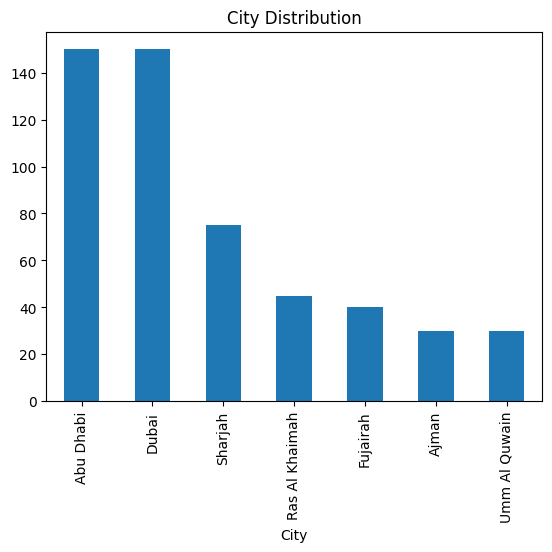

In [11]:
# Distribution of city
df["City"].value_counts().plot(kind = "bar", title = "City Distribution")
plt.show()

##Data Cleaning

In [12]:
# Change names of columns
df = df.rename(columns={'Attraction_ID': 'attraction_id', 'Name': 'name', 'City': 'city', 'Location': 'location', 'Description': 'description',
       'Categories': 'categories', 'Environment': 'environment', 'Reviews': 'reviews', 'Avg_Rating': 'rating'})
df.columns

Index(['attraction_id', 'name', 'city', 'location', 'description',
       'categories', 'environment', 'price_level', 'rating', 'reviews'],
      dtype='object')

In [13]:
# Split reviews to list
df["reviews"] = df["reviews"].apply(lambda x: [r.strip() for r in x.split("||")] if pd.notna(x) else pd.NA)

In [14]:
# Clean the review text

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [15]:
df["reviews"] = df["reviews"].apply(
    lambda x: [clean_text(r) for r in x] if isinstance(x, list) else pd.NA
)

In [16]:
df["reviews"].head()

,reviews
0,[abrahamic family house is built on a truly meaningful and visionary idea bringing the abrahamic religions together through a mosque a church and a synagogue in one place is powerful courageous an...
1,[its a safest beach clean and good atmosphere its an artificial beach so there dont have a waves and life guards are there there have a separate for families and single family has a ticket system ...
2,[absolutely worth visiting no matter if you have family and kids or you are just by yourself an 2hour tour provides you with sufficient information about falcons nature life cycle species feeding ...
3,[55 as an advertising and exhibition stand contractor we have had the opportunity to work at adnec centre abu dhabi on numerous occasions both as exhibitors and as booth builders for our clients m...
4,[amazing place with lot of activities for kids who grew up above 110cm while best for 130cm and higher indoor carts slides nets cave trampoline bounce castle and many more this ramadan great offer...


##Feature Engineering

In [17]:
attractions = df.copy()

In [18]:
attractions["kids_friendly"] = np.where(
    attractions["description"].str.lower().str.contains(
        "family|families|kids|children|child",
        na=False
    )
    |
    attractions["categories"].str.lower().str.contains(
        "family|families|kids|children|child",
        na=False
    ),
    "Yes",
    "No"
)

In [19]:
attractions["kids_friendly"].value_counts()

,count
kids_friendly,
No,328
Yes,192


In [20]:
attractions["rating"] = attractions["rating"] / 5

##Feature Selection

In [21]:
attractions_useful_features = ["name", "city", "description", "categories", "environment", "price_level", "kids_friendly", "rating", "review"]

In [22]:
attractions_content_columns = ["name", "city", "description", "categories"]

**Useful Features:**

The useful features are the attraction name, city, description, categories.

The name, city, description, and cetegories will be used for the content and will be used to calculate similarities.

The price level, city, kids friendly, and environment will be used for filtering.

The reviews for each attraction would later be predicted as either positive or negative and combined for the sentiment score. The ratings, sentiment score, and environment would later be used for the ranking with a formula. 75% similarity, 15% sentiment score, 10% ratings.

**Purpose:**

Recommend attractions that best match the visitor’s preferences using content-based filtering. The system filters attractions based on the selected city, budget, and environment, then ranks the candidates using similarity, sentiment score, and rating.

##Creating Attraction Content

In [23]:
attractions['content'] = (
    attractions['name'].fillna('') + ' ' +
    attractions['city'].fillna('') + ' ' +
    attractions['description'].fillna('') + ' ' +
    attractions['categories'].fillna('')
).str.lower()

In [24]:
display(
    attractions[['name', 'content']].head()
)

,name,content
0,Abrahamic Family House,"abrahamic family house abu dhabi a cultural and religious complex containing a mosque, church and synagogue. religious, cultural, architecture, educational"
1,Abu Dhabi Corniche,"abu dhabi corniche abu dhabi a long waterfront promenade with beaches, cycling paths and city views. waterfront, beach, cycling, family"
2,Abu Dhabi Falcon Hospital,"abu dhabi falcon hospital abu dhabi a specialist falcon hospital offering educational visitor tours. wildlife, cultural, educational"
3,Abu Dhabi National Exhibition Centre,"abu dhabi national exhibition centre abu dhabi a large exhibition and conference venue hosting public shows and events. events, exhibition, business"
4,Adrenark Adventure,"adrenark adventure abu dhabi an indoor adventure park with climbing, obstacle and family activities. adventure, family, sports"


##Creating User Profile

In [25]:
user_profile = {
    'user_id': '1245',
    'city': ['Dubai'],
    'attraction_preference': ['Beach', 'Desert', 'Parks'],
    'budget': 'Medium',
    'environment': ['Indoor', 'Outdoor'],
    'with_kids': 'Yes',
    'top_n': 5
}

In [26]:
user_query = " ".join([
    " ".join(user_profile["city"]),
    " ".join(user_profile["attraction_preference"]),
])

user_query

'Dubai Beach Desert Parks'

##Text Vectorizing

In [27]:
attractions_vectorizer = TfidfVectorizer(stop_words = 'english')
attractions_matrix = attractions_vectorizer.fit_transform(attractions['content'].fillna(""))
user_matrix = attractions_vectorizer.transform([user_query])

##Calculating User-to-Item Similarity

In [28]:
similarity_scores = cosine_similarity(user_matrix, attractions_matrix).flatten()

attractions["similarity_score"] = similarity_scores

display(
    attractions[["name", "price_level", "city", "categories", "similarity_score", "kids_friendly"]]
    .sort_values(by="similarity_score", ascending=False).head(10))


,name,price_level,city,categories,similarity_score,kids_friendly
171,Dubai Desert Conservation Reserve,High,Dubai,"Nature, Desert, Wildlife, Adventure",0.405028,No
203,Riverland Dubai,Free,Dubai,"Entertainment, Dining, Family",0.350956,Yes
193,MOTIONGATE Dubai,High,Dubai,"Theme Park, Entertainment, Family",0.325270,Yes
137,Al Khatim Desert,Free,Abu Dhabi,"Desert, Camping, Adventure, Nature",0.284028,No
188,Kite Beach,Free,Dubai,"Beach, Sports, Family",0.283519,Yes
237,Jumeirah Public Beach,Free,Dubai,"Beach, Family, Photography",0.280563,Yes
69,Jebel Hafit Desert Park,Medium,Abu Dhabi,"Desert, Historical, Adventure, Camping",0.275946,No
262,Marina Beach,Free,Dubai,"Beach, Waterfront, Family",0.271436,Yes
274,Black Palace Beach,Free,Dubai,"Beach, Nature, Photography",0.266035,No
280,Fire Course,High,Dubai,"Golf, Sports, Desert",0.261567,No


needs filtering as they are from different cities, not very kids friendly

##Applying Filters

In [29]:
candidates_df = attractions.copy()

# City
candidates_df = candidates_df[
    candidates_df["city"].str.lower().isin(
        [city.lower() for city in user_profile["city"]]
    )
].copy()

# Environment
candidates_df = candidates_df[
    candidates_df["environment"].str.lower().isin(
        [environment.lower() for environment in user_profile["environment"]]
    )
].copy()

# Kids friendly
if user_profile["with_kids"].lower() == "yes":
    candidates_df = candidates_df[
        candidates_df["kids_friendly"].str.lower() == "yes"
    ].copy()

budget = user_profile["budget"].lower()

# Budget
if budget == "low":
    candidates_df = candidates_df[
        candidates_df["price_level"].str.lower().isin(["free", "low"]
        )
    ].copy()

elif budget == "medium":
    candidates_df = candidates_df[
        candidates_df["price_level"].str.lower().isin(["free", "low", "medium"]
        )
    ].copy()

elif budget == "high":
    candidates_df = candidates_df[
        candidates_df["price_level"].str.lower().isin(["free", "low", "medium", "high"]
        )
    ].copy()

candidates_df["fallback_stage"] = "strict_match"

In [30]:
display(
    candidates_df[["name", "price_level", "city", "categories", "environment", "kids_friendly", "similarity_score", "fallback_stage"]]
    .sort_values(by="similarity_score", ascending=False).head(10)
)

,name,price_level,city,categories,environment,kids_friendly,similarity_score,fallback_stage
203,Riverland Dubai,Free,Dubai,"Entertainment, Dining, Family",Outdoor,Yes,0.350956,strict_match
188,Kite Beach,Free,Dubai,"Beach, Sports, Family",Outdoor,Yes,0.283519,strict_match
237,Jumeirah Public Beach,Free,Dubai,"Beach, Family, Photography",Outdoor,Yes,0.280563,strict_match
262,Marina Beach,Free,Dubai,"Beach, Waterfront, Family",Outdoor,Yes,0.271436,strict_match
238,Sunset Beach,Free,Dubai,"Beach, Photography, Family",Outdoor,Yes,0.240301,strict_match
241,Umm Suqeim Park,Low,Dubai,"Park, Family, Beach",Outdoor,Yes,0.212897,strict_match
240,Jumeirah Open Beach,Free,Dubai,"Beach, Sports, Family",Outdoor,Yes,0.205328,strict_match
184,J1 Beach,Free,Dubai,"Beach, Dining, Entertainment, Family",Outdoor,Yes,0.199651,strict_match
153,Al Mamzar Beach Park,Low,Dubai,"Beach, Park, Family",Outdoor,Yes,0.194649,strict_match
208,The Dubai Fountain,Free,Dubai,"Entertainment, Landmark, Family",Outdoor,Yes,0.116460,strict_match


##Fallback Stage

In [31]:
required_count = user_profile["top_n"]

def add_new_candidates(candidates_df,new_candidates,fallback_stage,required_count):
    needed = required_count - len(candidates_df)

    new_candidates = new_candidates.copy()
    new_candidates["fallback_stage"] = fallback_stage

    new_candidates = new_candidates[
        ~new_candidates["attraction_id"].isin(
            candidates_df["attraction_id"]
        )
    ]

    new_candidates = new_candidates.sort_values(
        by="similarity_score",
        ascending=False
    )

    candidates_df = pd.concat([
        candidates_df,
        new_candidates.head(needed)
    ])

    return candidates_df

In [32]:
# Relaxing environment
if len(candidates_df) < required_count:

    relaxed_environment_df = attractions[
        attractions["city"].str.lower().isin(
            [city.lower() for city in user_profile["city"]]
        ) &
        attractions["price_level"].str.lower().isin(budget)
    ].copy()

    if user_profile["with_kids"].lower() == "yes":
        relaxed_environment_df = relaxed_environment_df[
            relaxed_environment_df["kids_friendly"].str.lower() == "yes"
        ].copy()

    candidates_df = add_new_candidates(
        candidates_df,
        relaxed_environment_df,
        "relaxed_environment",
        required_count
    )

display(
    candidates_df[["name", "price_level", "city", "categories", "environment", "kids_friendly", "similarity_score", "fallback_stage"]]
    .sort_values(by="similarity_score", ascending=False).head(10)
)

,name,price_level,city,categories,environment,kids_friendly,similarity_score,fallback_stage
203,Riverland Dubai,Free,Dubai,"Entertainment, Dining, Family",Outdoor,Yes,0.350956,strict_match
188,Kite Beach,Free,Dubai,"Beach, Sports, Family",Outdoor,Yes,0.283519,strict_match
237,Jumeirah Public Beach,Free,Dubai,"Beach, Family, Photography",Outdoor,Yes,0.280563,strict_match
262,Marina Beach,Free,Dubai,"Beach, Waterfront, Family",Outdoor,Yes,0.271436,strict_match
238,Sunset Beach,Free,Dubai,"Beach, Photography, Family",Outdoor,Yes,0.240301,strict_match
241,Umm Suqeim Park,Low,Dubai,"Park, Family, Beach",Outdoor,Yes,0.212897,strict_match
240,Jumeirah Open Beach,Free,Dubai,"Beach, Sports, Family",Outdoor,Yes,0.205328,strict_match
184,J1 Beach,Free,Dubai,"Beach, Dining, Entertainment, Family",Outdoor,Yes,0.199651,strict_match
153,Al Mamzar Beach Park,Low,Dubai,"Beach, Park, Family",Outdoor,Yes,0.194649,strict_match
208,The Dubai Fountain,Free,Dubai,"Entertainment, Landmark, Family",Outdoor,Yes,0.116460,strict_match


In [33]:
# Relaxing budget and environment
if len(candidates_df) < required_count:

    relaxed_budget_environment_df = attractions[
        attractions["city"].str.lower().isin(
            [city.lower() for city in user_profile["city"]]
        )
    ].copy()

    if user_profile["with_kids"].lower() == "yes":
        relaxed_budget_environment_df = relaxed_budget_environment_df[
            relaxed_budget_environment_df["kids_friendly"].str.lower() == "yes"
        ].copy()

    candidates_df = add_new_candidates(
        candidates_df,
        relaxed_budget_environment_df,
        "relaxed_budget_environment",
        required_count
    )

display(
    candidates_df[["name", "price_level", "city", "categories", "environment", "kids_friendly", "similarity_score", "fallback_stage"]]
    .sort_values(by="similarity_score", ascending=False).head(10)
)

,name,price_level,city,categories,environment,kids_friendly,similarity_score,fallback_stage
203,Riverland Dubai,Free,Dubai,"Entertainment, Dining, Family",Outdoor,Yes,0.350956,strict_match
188,Kite Beach,Free,Dubai,"Beach, Sports, Family",Outdoor,Yes,0.283519,strict_match
237,Jumeirah Public Beach,Free,Dubai,"Beach, Family, Photography",Outdoor,Yes,0.280563,strict_match
262,Marina Beach,Free,Dubai,"Beach, Waterfront, Family",Outdoor,Yes,0.271436,strict_match
238,Sunset Beach,Free,Dubai,"Beach, Photography, Family",Outdoor,Yes,0.240301,strict_match
241,Umm Suqeim Park,Low,Dubai,"Park, Family, Beach",Outdoor,Yes,0.212897,strict_match
240,Jumeirah Open Beach,Free,Dubai,"Beach, Sports, Family",Outdoor,Yes,0.205328,strict_match
184,J1 Beach,Free,Dubai,"Beach, Dining, Entertainment, Family",Outdoor,Yes,0.199651,strict_match
153,Al Mamzar Beach Park,Low,Dubai,"Beach, Park, Family",Outdoor,Yes,0.194649,strict_match
208,The Dubai Fountain,Free,Dubai,"Entertainment, Landmark, Family",Outdoor,Yes,0.116460,strict_match


In [34]:
# Expanding city
if len(candidates_df) < required_count:

    relaxed_city_df = attractions.copy()

    if user_profile["with_kids"].lower() == "yes":
        relaxed_city_df = relaxed_city_df[
            relaxed_city_df["kids_friendly"].str.lower() == "yes"
        ].copy()

    candidates_df = add_new_candidates(
        candidates_df,
        relaxed_city_df,
        "expanded_city",
        required_count
    )

display(
    candidates_df[["name", "price_level", "city", "categories", "environment", "kids_friendly", "similarity_score", "fallback_stage"]]
    .sort_values(by="similarity_score", ascending=False).head(10)
)

,name,price_level,city,categories,environment,kids_friendly,similarity_score,fallback_stage
203,Riverland Dubai,Free,Dubai,"Entertainment, Dining, Family",Outdoor,Yes,0.350956,strict_match
188,Kite Beach,Free,Dubai,"Beach, Sports, Family",Outdoor,Yes,0.283519,strict_match
237,Jumeirah Public Beach,Free,Dubai,"Beach, Family, Photography",Outdoor,Yes,0.280563,strict_match
262,Marina Beach,Free,Dubai,"Beach, Waterfront, Family",Outdoor,Yes,0.271436,strict_match
238,Sunset Beach,Free,Dubai,"Beach, Photography, Family",Outdoor,Yes,0.240301,strict_match
241,Umm Suqeim Park,Low,Dubai,"Park, Family, Beach",Outdoor,Yes,0.212897,strict_match
240,Jumeirah Open Beach,Free,Dubai,"Beach, Sports, Family",Outdoor,Yes,0.205328,strict_match
184,J1 Beach,Free,Dubai,"Beach, Dining, Entertainment, Family",Outdoor,Yes,0.199651,strict_match
153,Al Mamzar Beach Park,Low,Dubai,"Beach, Park, Family",Outdoor,Yes,0.194649,strict_match
208,The Dubai Fountain,Free,Dubai,"Entertainment, Landmark, Family",Outdoor,Yes,0.116460,strict_match


##Loading the Trained Sentiment Model

In [35]:
import joblib

model = joblib.load("/content/sentiment_model_best.joblib")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.1 when using version 1.6.1. This might lead to breaking c

In [36]:
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [37]:
print(model.named_steps)

{'TF-IDF': TfidfVectorizer(max_features=15000, ngram_range=(1, 2)), 'Classifier': LogisticRegression(C=5, max_iter=1000, random_state=42)}


In [38]:
print(model.named_steps["Classifier"].classes_)

[0 1]


## Using the Sentiment Model on Our Reviews

In [39]:
# Use model to predict each review in each row/acttraction
review_rows = []

for _, row in attractions.iterrows():
  if isinstance(row["reviews"], list):
    for review in row["reviews"]:
      review_rows.append({
            "attraction_id": row["attraction_id"],
            "name": row["name"],
            "review": review
        })

attractions_review = pd.DataFrame(review_rows)

attractions_review["predicted_sentiment"] = model.predict(
    attractions_review["review"]
)

sentiment_mapping = {
    0: -1,
    1: 1
}

attractions_review["sentiment_value"] = (
    attractions_review["predicted_sentiment"]
    .map(sentiment_mapping)
)

sentiment_by_attraction = (
    attractions_review
    .groupby("attraction_id", as_index=False)["sentiment_value"]
    .mean()
    .rename(columns={"sentiment_value": "sentiment_score"})
)

sentiment_by_attraction.head()


,attraction_id,sentiment_score
0,1001,1.0
1,1002,1.0
2,1003,1.0
3,1004,0.6
4,1005,1.0


In [40]:
attractions = attractions.merge(
    sentiment_by_attraction,
    on="attraction_id",
    how="left"
).copy()

attractions["sentiment_score"] = (attractions["sentiment_score"].fillna(0))

attractions["normalized_sentiment"] = (attractions["sentiment_score"] + 1) / 2

## Final Rank Score with Sentiment Score

In [41]:
candidates_df = candidates_df.merge(
    sentiment_by_attraction,
    on="attraction_id",
    how="left"
).copy()

candidates_df["sentiment_score"] = (candidates_df["sentiment_score"].fillna(0))

candidates_df["normalized_sentiment"] = (candidates_df["sentiment_score"] + 1) / 2

candidates_df["final_score"] = (
    0.75 * candidates_df["similarity_score"] +
    0.15 * candidates_df["rating"] +
    0.10 * candidates_df["normalized_sentiment"]
)

In [42]:
recommendations = (
    candidates_df
    .sort_values("final_score", ascending=False)
    .head(user_profile["top_n"])
    .reset_index(drop=True)
).copy()

In [43]:
recommendations[[
    "name",
    "city",
    "categories",
    "rating",
    "similarity_score",
    "sentiment_score",
    "final_score"
]]

,name,city,categories,rating,similarity_score,sentiment_score,final_score
0,Riverland Dubai,Dubai,"Entertainment, Dining, Family",0.90,0.350956,0.6,0.478217
1,Kite Beach,Dubai,"Beach, Sports, Family",0.92,0.283519,1.0,0.450639
2,Jumeirah Public Beach,Dubai,"Beach, Family, Photography",0.92,0.280563,1.0,0.448422
3,Marina Beach,Dubai,"Beach, Waterfront, Family",0.92,0.271436,1.0,0.441577
4,Sunset Beach,Dubai,"Beach, Photography, Family",0.88,0.240301,1.0,0.412226


##Building Reason with Sentiment Score

In [44]:
def attraction_reason_with_sentiment(row, user_profile):

    reasons = []

    if row["fallback_stage"] == "strict_match":
        reasons.append(
            "matches your city, environment and budget preferences"
        )

    elif row["fallback_stage"] == "relaxed_environment":
        reasons.append(
            "matches your city and budget preferences"
        )
        reasons.append(
            "environment preference was relaxed"
        )

    elif row["fallback_stage"] == "relaxed_budget_environment":
        reasons.append(
            "matches your city preference"
        )
        reasons.append(
            "budget and environment preferences were relaxed"
        )

    elif row["fallback_stage"] == "expanded_city":
        reasons.append(
            "the search was expanded to other cities"
        )
        reasons.append(
            "city, budget and environment preferences were relaxed"
        )

    if user_profile["with_kids"].lower() == "yes":
        if row["kids_friendly"].lower() == "yes":
            reasons.append(
                "is suitable for kids"
            )

    if row["rating"] >= 0.90:
        reasons.append(
            "has excellent ratings"
        )
    else:
        reasons.append(
            "has good ratings"
        )

    if row["sentiment_score"] > 0.5:
        reasons.append(
            "has mostly positive reviews"
        )

    elif row["sentiment_score"] > 0:
        reasons.append(
            "has positive reviews"
        )

    elif row["sentiment_score"] == 0:
        reasons.append(
            "has neutral reviews"
        )

    return "; ".join(reasons) + "."

##Building Recommendation Function with Sentiment Score

In [45]:
def recommend_attractions_with_sentiment(user_profile, attractions, vectorizer, attractions_matrix):

    required_count = user_profile["top_n"]

    user_query = " ".join([
        " ".join(user_profile["city"]),
        " ".join(user_profile["attraction_preference"])
    ])

    # Vectorize
    user_matrix = vectorizer.transform([user_query])

    # Calculate similarity
    similarity_scores = cosine_similarity(
        user_matrix,
        attractions_matrix
    ).flatten()

    attractions_copy = attractions.copy()
    attractions_copy["similarity_score"] = similarity_scores

    cities = [
        city.lower()
        for city in user_profile["city"]
    ]

    environments = [
        environment.lower()
        for environment in user_profile["environment"]
    ]

    budget = user_profile["budget"].lower()

    if budget == "low":
        budget_levels = ["free", "low"]

    elif budget == "medium":
        budget_levels = ["free", "low", "medium"]

    elif budget == "high":
        budget_levels = ["free", "low", "medium", "high"]

    else:
        budget_levels = ["free", "low", "medium", "high"]

    # Strict match
    candidates_df = attractions_copy[
        attractions_copy["city"].str.lower().isin(cities) &
        attractions_copy["environment"].str.lower().isin(environments) &
        attractions_copy["price_level"].str.lower().isin(budget_levels)
    ].copy()

    if user_profile["with_kids"].lower() == "yes":
        candidates_df = candidates_df[
            candidates_df["kids_friendly"].str.lower() == "yes"
        ].copy()

    candidates_df["fallback_stage"] = "strict_match"

    # Relax environment
    if len(candidates_df) < required_count:

        relaxed_environment_df = attractions_copy[
            attractions_copy["city"].str.lower().isin(cities) &
            attractions_copy["price_level"].str.lower().isin(
                budget_levels
            )
        ].copy()

        if user_profile["with_kids"].lower() == "yes":
            relaxed_environment_df = relaxed_environment_df[
                relaxed_environment_df["kids_friendly"].str.lower() == "yes"
            ].copy()

        candidates_df = add_new_candidates(
            candidates_df,
            relaxed_environment_df,
            "relaxed_environment",
            required_count
        )

    # Relax budget and environment
    if len(candidates_df) < required_count:

        relaxed_budget_environment_df = attractions_copy[
            attractions_copy["city"].str.lower().isin(cities)
        ].copy()

        if user_profile["with_kids"].lower() == "yes":
            relaxed_budget_environment_df = (
                relaxed_budget_environment_df[
                    relaxed_budget_environment_df[
                        "kids_friendly"
                    ].str.lower() == "yes"
                ].copy()
            )

        candidates_df = add_new_candidates(
            candidates_df,
            relaxed_budget_environment_df,
            "relaxed_budget_environment",
            required_count
        )

    # Expand city
    if len(candidates_df) < required_count:

        expanded_city_df = attractions_copy.copy()

        if user_profile["with_kids"].lower() == "yes":
            expanded_city_df = expanded_city_df[
                expanded_city_df["kids_friendly"].str.lower() == "yes"
            ].copy()

        candidates_df = add_new_candidates(
            candidates_df,
            expanded_city_df,
            "expanded_city",
            required_count
        )

    # Calculate final ranking score
    candidates_df["final_score"] = (
        0.75 * candidates_df["similarity_score"] +
        0.15 * candidates_df["rating"] +
        0.10 * candidates_df["normalized_sentiment"]
    )

    final_recommendations = candidates_df.sort_values(
        by="final_score",
        ascending=False
    ).head(required_count).copy()

    final_recommendations["rank"] = range(
        1,
        len(final_recommendations) + 1
    )

    final_recommendations["recommendation_reason"] = (
        final_recommendations.apply(
            lambda row: attraction_reason_with_sentiment(
                row,
                user_profile
            ),
            axis=1
        )
    )

    return final_recommendations[
        [
            "name",
            "price_level",
            "city",
            "categories",
            "environment",
            "kids_friendly",
            "similarity_score",
            "rating",
            "normalized_sentiment",
            "final_score",
            "fallback_stage",
            "recommendation_reason",
            "rank"
        ]
    ]

##Testing New Function

In [46]:
user_profile1 = {
    "city": ["Dubai"],
    "budget": "medium",
    "environment": ["Indoor"],
    "attraction_preference": ["Shopping", "Culture"],
    "with_kids": "No",
    "top_n": 5
}

user_profile2 = {
    "city": ["Abu Dhabi"],
    "budget": "low",
    "environment": ["Outdoor"],
    "attraction_preference": ["Adventure", "Nature"],
    "with_kids": "Yes",
    "top_n": 5
}

user_profile3 = {
    "city": ["Umm Al Quwain"],
    "budget": "low",
    "environment": ["Indoor"],
    "attraction_preference": ["Culture", "Park"],
    "with_kids": "Yes",
    "top_n": 7
}

In [47]:
user_profile1

{'city': ['Dubai'],
 'budget': 'medium',
 'environment': ['Indoor'],
 'attraction_preference': ['Shopping', 'Culture'],
 'with_kids': 'No',
 'top_n': 5}

In [48]:
display(recommend_attractions_with_sentiment(user_profile1, attractions, attractions_vectorizer, attractions_matrix))

,name,price_level,city,categories,environment,kids_friendly,similarity_score,rating,normalized_sentiment,final_score,fallback_stage,recommendation_reason,rank
235,Mercato Shopping Mall,Free,Dubai,"Shopping, Entertainment, Architecture",Indoor,Yes,0.326821,0.88,1.0,0.477116,strict_match,"matches your city, environment and budget preferences; has good ratings; has mostly positive reviews.",1
288,City Centre Mirdif,Free,Dubai,"Shopping, Entertainment, Family",Indoor,Yes,0.281703,0.92,1.0,0.449277,strict_match,"matches your city, environment and budget preferences; has excellent ratings; has mostly positive reviews.",2
196,Mall of the Emirates,Free,Dubai,"Shopping, Entertainment, Family",Indoor,Yes,0.267393,0.94,1.0,0.441545,strict_match,"matches your city, environment and budget preferences; has excellent ratings; has mostly positive reviews.",3
209,The Dubai Mall,Free,Dubai,"Shopping, Entertainment, Family",Indoor,Yes,0.333299,0.94,0.5,0.440974,strict_match,"matches your city, environment and budget preferences; has excellent ratings; has neutral reviews.",4
270,Nakheel Mall,Free,Dubai,"Shopping, Entertainment, Family",Indoor,Yes,0.266971,0.90,0.8,0.415228,strict_match,"matches your city, environment and budget preferences; has excellent ratings; has mostly positive reviews.",5


In [49]:
user_profile2

{'city': ['Abu Dhabi'],
 'budget': 'low',
 'environment': ['Outdoor'],
 'attraction_preference': ['Adventure', 'Nature'],
 'with_kids': 'Yes',
 'top_n': 5}

In [50]:
display(recommend_attractions_with_sentiment(user_profile2, attractions, attractions_vectorizer, attractions_matrix))

,name,price_level,city,categories,environment,kids_friendly,similarity_score,rating,normalized_sentiment,final_score,fallback_stage,recommendation_reason,rank
133,Al Shahama Park,Free,Abu Dhabi,"Park, Family, Nature",Outdoor,Yes,0.233155,0.88,1.0,0.406866,strict_match,"matches your city, environment and budget preferences; is suitable for kids; has good ratings; has mostly positive reviews.",1
1,Abu Dhabi Corniche,Free,Abu Dhabi,"Waterfront, Beach, Cycling, Family",Outdoor,Yes,0.223457,0.90,1.0,0.402592,strict_match,"matches your city, environment and budget preferences; is suitable for kids; has excellent ratings; has mostly positive reviews.",2
127,Al Shamkha Park,Free,Abu Dhabi,"Park, Family, Nature",Outdoor,Yes,0.207667,0.90,1.0,0.390750,strict_match,"matches your city, environment and budget preferences; is suitable for kids; has excellent ratings; has mostly positive reviews.",3
85,Lake Park,Free,Abu Dhabi,"Park, Family, Nature",Outdoor,Yes,0.203393,0.90,1.0,0.387545,strict_match,"matches your city, environment and budget preferences; is suitable for kids; has excellent ratings; has mostly positive reviews.",4
84,Family Park,Free,Abu Dhabi,"Park, Family, Nature",Outdoor,Yes,0.205156,0.88,1.0,0.385867,strict_match,"matches your city, environment and budget preferences; is suitable for kids; has good ratings; has mostly positive reviews.",5


In [51]:
user_profile3

{'city': ['Umm Al Quwain'],
 'budget': 'low',
 'environment': ['Indoor'],
 'attraction_preference': ['Culture', 'Park'],
 'with_kids': 'Yes',
 'top_n': 7}

In [52]:
display(recommend_attractions_with_sentiment(user_profile3, attractions, attractions_vectorizer, attractions_matrix))

,name,price_level,city,categories,environment,kids_friendly,similarity_score,rating,normalized_sentiment,final_score,fallback_stage,recommendation_reason,rank
511,Al Salamah Park,Free,Umm Al Quwain,"Park, Family, Nature",Outdoor,Yes,0.473782,0.84,1.0,0.581337,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has good ratings; has mostly positive reviews.,1
500,Umm Al Quwain Corniche,Free,Umm Al Quwain,"Waterfront, Walking, Family",Outdoor,Yes,0.449886,0.84,1.0,0.563415,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has good ratings; has mostly positive reviews.,2
513,Falaj Al Mualla Gardens Park,Free,Umm Al Quwain,"Park, Family, Garden",Outdoor,Yes,0.417838,0.74,1.0,0.524379,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has good ratings; has mostly positive reviews.,3
499,Umm Al Quwain Beach,Free,Umm Al Quwain,"Beach, Camping, Family",Outdoor,Yes,0.384475,0.86,0.8,0.497356,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has good ratings; has mostly positive reviews.,4
518,Umm Al Quwain Equestrian Club,High,Umm Al Quwain,"Equestrian, Sports, Family","Outdoor, Indoor",Yes,0.331655,0.96,1.0,0.492741,relaxed_budget_environment,matches your city preference; budget and environment preferences were relaxed; is suitable for kids; has excellent ratings; has mostly positive reviews.,5
509,Al Raas Public Beach,Free,Umm Al Quwain,"Beach, Family, Nature",Outdoor,Yes,0.250581,0.94,1.0,0.428936,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has excellent ratings; has mostly positive reviews.,6
493,Dreamland Aqua Park,High,Umm Al Quwain,"Water Park, Family, Adventure",Outdoor,Yes,0.327421,0.80,0.6,0.425566,relaxed_budget_environment,matches your city preference; budget and environment preferences were relaxed; is suitable for kids; has good ratings; has positive reviews.,7


## Saving Models for FastAPI

In [53]:
# Saving the final dataset
attractions.to_csv(
    "attractions.csv",
    index=False
)

print("attractions.csv saved successfully.")

attractions.csv saved successfully.


In [54]:
# Saving the

with open("attractions_vectorizer.joblib", "wb") as f:
    joblib.dump(attractions_vectorizer, f)

with open("attractions_matrix.joblib", "wb") as f:
    joblib.dump(attractions_matrix, f)

print("attractions_vectorizer.joblib and attractions_matrix.joblib saved successfully.")

attractions_vectorizer.joblib and attractions_matrix.joblib saved successfully.


In [55]:
import inspect

with open("attraction_recommender.py", "w") as f:
    f.write("import pandas as pd\n")
    f.write("from sklearn.feature_extraction.text import TfidfVectorizer\n")
    f.write("from sklearn.metrics.pairwise import cosine_similarity\n\n")

    f.write(inspect.getsource(add_new_candidates))
    f.write("\n\n")
    f.write(inspect.getsource(attraction_reason_with_sentiment))
    f.write("\n\n")
    f.write(inspect.getsource(recommend_attractions_with_sentiment))

## Testing the Saved Model

In [56]:
attractions = pd.read_csv("/content/attractions.csv")
attractions_vectorizer = joblib.load("/content/attractions_vectorizer.joblib")
attractions_matrix = joblib.load("/content/attractions_matrix.joblib")


from attraction_recommender import recommend_attractions_with_sentiment

recommendations = recommend_attractions_with_sentiment(
    user_profile3,
    attractions,
    attractions_vectorizer,
    attractions_matrix
)

recommendations

,name,price_level,city,categories,environment,kids_friendly,similarity_score,rating,normalized_sentiment,final_score,fallback_stage,recommendation_reason,rank
511,Al Salamah Park,Free,Umm Al Quwain,"Park, Family, Nature",Outdoor,Yes,0.473782,0.84,1.0,0.581337,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has good ratings; has mostly positive reviews.,1
500,Umm Al Quwain Corniche,Free,Umm Al Quwain,"Waterfront, Walking, Family",Outdoor,Yes,0.449886,0.84,1.0,0.563415,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has good ratings; has mostly positive reviews.,2
513,Falaj Al Mualla Gardens Park,Free,Umm Al Quwain,"Park, Family, Garden",Outdoor,Yes,0.417838,0.74,1.0,0.524379,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has good ratings; has mostly positive reviews.,3
499,Umm Al Quwain Beach,Free,Umm Al Quwain,"Beach, Camping, Family",Outdoor,Yes,0.384475,0.86,0.8,0.497356,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has good ratings; has mostly positive reviews.,4
518,Umm Al Quwain Equestrian Club,High,Umm Al Quwain,"Equestrian, Sports, Family","Outdoor, Indoor",Yes,0.331655,0.96,1.0,0.492741,relaxed_budget_environment,matches your city preference; budget and environment preferences were relaxed; is suitable for kids; has excellent ratings; has mostly positive reviews.,5
509,Al Raas Public Beach,Free,Umm Al Quwain,"Beach, Family, Nature",Outdoor,Yes,0.250581,0.94,1.0,0.428936,relaxed_environment,matches your city and budget preferences; environment preference was relaxed; is suitable for kids; has excellent ratings; has mostly positive reviews.,6
493,Dreamland Aqua Park,High,Umm Al Quwain,"Water Park, Family, Adventure",Outdoor,Yes,0.327421,0.80,0.6,0.425566,relaxed_budget_environment,matches your city preference; budget and environment preferences were relaxed; is suitable for kids; has good ratings; has positive reviews.,7
